# Générateur de Contenu Personnalisé Basé sur l'IA
**Outils :** Python · NumPy · Pandas · Faker · Matplotlib · Seaborn · SciPy

## Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cosine
from functools import reduce
from faker import Faker




## Partie 1 — Définir les profils et préférences des utilisateurs

In [ ]:
# reproductibilité
np.random.seed(42)
Faker.seed(42)

In [ ]:
# Initialisation de Faker
fake = Faker('fr_FR')


INTERESTS = [
    "fitness", "musique", "technologie", "cuisine", "voyage",
    "cinéma", "lecture", "gaming", "mode", "photographie"
]

ACTIVITY_MAPPING = {
    "fitness": [
        "regardé une vidéo d'entraînement",
        "regardé un tutoriel yoga",
        "regardé une séance HIIT",
        "acheté des protéines en poudre",
        "acheté des bandes de résistance",
        "acheté des chaussures de running",
        "aimé une publication de salle de sport",
        "aimé une photo de transformation",
        "rejoint une salle de sport",
        "complété un défi 30 jours",
        "suivi une course matinale",
        "lu un blog fitness",
        "partagé un conseil nutrition",
    ],
    "musique": [
        "regardé un clip musical",
        "regardé un concert en direct",
        "regardé un tutoriel guitare",
        "acheté des écouteurs",
        "acheté un billet de concert",
        "acheté un vinyle",
        "aimé une chanson",
        "aimé une critique d'album",
        "assisté à un concert",
        "streamé un album",
        "créé une playlist",
        "partagé une recommandation musicale",
        "suivi un artiste",
        "téléchargé un épisode de podcast musical",
    ],
    "technologie": [
        "regardé une conférence sur l'IA",
        "regardé un tutoriel de programmation",
        "regardé une revue de produit tech",
        "lu un blog tech",
        "lu un article de recherche en IA",
        "lu une newsletter développeur",
        "acheté un ordinateur portable",
        "acheté une montre connectée",
        "acheté un clavier mécanique",
        "aimé un article sur l'IA",
        "aimé une publication startup",
        "contribué à l'open source",
        "complété un défi de programmation",
        "étoilé un dépôt GitHub",
        "déployé un projet personnel",
    ],
    "cuisine": [
        "regardé une émission culinaire",
        "regardé un tutoriel recette",
        "regardé un cours de pâtisserie",
        "acheté des ingrédients",
        "acheté un gadget de cuisine",
        "acheté un livre de recettes",
        "aimé une publication de recette",
        "aimé une photo culinaire",
        "essayé une nouvelle recette",
        "préparé les repas de la semaine",
        "visité un marché alimentaire",
        "partagé une recette",
        "suivi un chef",
        "laissé un avis sur un restaurant",
    ],
    "voyage": [
        "regardé un vlog de voyage",
        "regardé un guide de destination",
        "regardé des conseils de bagages",
        "réservé un vol",
        "réservé un hôtel",
        "réservé une visite guidée",
        "acheté une valise",
        "acheté un adaptateur de voyage",
        "acheté une assurance voyage",
        "aimé une photo de voyage",
        "aimé un itinéraire de voyage",
        "enregistré dans un hôtel",
        "laissé un avis sur une attraction",
        "partagé un conseil de voyage",
        "suivi un blogueur voyage",
    ],
    "cinéma": [
        "regardé un film",
        "regardé une bande-annonce",
        "regardé les coulisses d'un film",
        "regardé un documentaire",
        "regardé une analyse cinématographique",
        "acheté un abonnement streaming",
        "acheté un billet de cinéma",
        "noté un film",
        "aimé une critique de film",
        "créé une liste de films à voir",
        "partagé une recommandation de film",
        "suivi un critique de cinéma",
        "assisté à un festival de cinéma",
    ],
    "lecture": [
        "lu un roman",
        "lu un livre de science-fiction",
        "lu une biographie",
        "lu un livre de développement personnel",
        "lu un manga",
        "acheté un ebook",
        "acheté un livre papier",
        "acheté un livre audio",
        "aimé une critique de livre",
        "aimé une liste de lecture",
        "rejoint un club de lecture",
        "partagé une recommandation de livre",
        "suivi un auteur",
        "terminé un défi lecture",
    ],
    "gaming": [
        "regardé un walkthrough de jeu",
        "regardé un tournoi esport",
        "regardé une revue de jeu",
        "acheté un jeu vidéo",
        "acheté un casque gaming",
        "acheté une manette",
        "aimé un clip de jeu",
        "joué en multijoueur",
        "complété le mode histoire",
        "rejoint une communauté gaming",
        "partagé un clip de gameplay",
        "suivi un streamer",
        "participé à un test bêta",
    ],
    "mode": [
        "regardé un défilé de mode",
        "regardé des conseils stylisme",
        "regardé une vidéo haul",
        "acheté des vêtements",
        "acheté des sneakers",
        "acheté des accessoires",
        "aimé une publication tenue",
        "aimé une photo streetwear",
        "suivi un influenceur mode",
        "sauvegardé une inspiration tenue",
        "partagé une tenue du jour",
        "visité une boutique",
        "laissé un avis sur un achat",
    ],
    "photographie": [
        "regardé un tutoriel photo",
        "regardé un walkthrough de retouche",
        "regardé une revue de matériel photo",
        "acheté un objectif",
        "acheté un trépied",
        "acheté un logiciel de retouche",
        "aimé une photo",
        "aimé un conseil photo",
        "retouché une photo sur Lightroom",
        "mis en ligne un portfolio photo",
        "rejoint une communauté photo",
        "partagé un conseil photo",
        "suivi un photographe",
        "participé à un concours photo",
    ],
}


def generate_user(user_id):
    name = fake.name()
    age = np.random.randint(18, 66)
    num_interests = np.random.randint(1,4)
    interests = list(np.random.choice(INTERESTS, size=num_interests, replace=False))
    num_activities = np.random.randint(3, 7)
    activity_log = []
    for _ in range(num_activities):
        chosen_interest = np.random.choice(interests)
        activity = np.random.choice(ACTIVITY_MAPPING[chosen_interest])
        activity_log.append(activity)

    return {
        "name":         name,
        "age":          age,
        "interests":    interests,
        "activity_log": activity_log
    }

def generate_users_dataset(n_users=100):
    users_list = []
    for i in range(n_users):
        user = generate_user(i + 1)
        users_list.append(user)

    df = pd.DataFrame(users_list)
    return df

print('EXEMPLE DÉTAILLÉ')
df_users = generate_users_dataset(100)
print(df_users)

EXEMPLE DÉTAILLÉ
                        name  age                      interests  \
0           Alexandre Traore   56                      [cuisine]   
1       Gérard-Frédéric Joly   61    [photographie, technologie]   
2                Yves Traore   45        [musique, mode, gaming]   
3        Aurore Maury-Briand   26           [mode, photographie]   
4            Alexandre Morin   59          [voyage, technologie]   
..                       ...  ...                            ...   
95          Capucine Legrand   57              [voyage, musique]   
96  Frédérique Guillou-Aubry   53  [photographie, cuisine, mode]   
97             Jérôme Muller   30                         [mode]   
98    Julien Jacquet-Barbier   36              [voyage, fitness]   
99         Madeleine Raymond   44                      [lecture]   

                                         activity_log  
0   [aimé une photo culinaire, regardé un cours de...  
1   [acheté un clavier mécanique, rejoint une comm... 

## Partie 2 — Générer et analyser les données

In [7]:

df_brut = generate_users_dataset(200)

# --- Introduction volontaire de valeurs manquantes ---
df_brut['age'] = df_brut['age'].astype(float)
indices_age_manquant     = np.random.choice(200, size=15, replace=False)
indices_journal_manquant = np.random.choice(200, size=10, replace=False)
indices_nom_doublon      = np.random.choice(200, size=5,  replace=False)

for i in indices_age_manquant:
    df_brut.at[i, 'age'] = np.nan
for i in indices_journal_manquant:
    df_brut.at[i, 'activity_log'] = None
for i in indices_nom_doublon:
    df_brut.at[i, 'name'] = df_brut.at[0, 'name']  # doublons sur le premier nom

print(f"Taille avant nettoyage : {len(df_brut)} lignes")
print(f"Valeurs manquantes :\n{df_brut.isnull().sum()}")
print(f"Doublons sur 'name' : {df_brut.duplicated(subset=['name']).sum()}")
df_brut.head()

Taille avant nettoyage : 200 lignes
Valeurs manquantes :
name             0
age             15
interests        0
activity_log    10
dtype: int64
Doublons sur 'name' : 4


,name,age,interests,activity_log
0,Adrienne Le Dupré,52.0,[mode],"[regardé des conseils stylisme, laissé un avis..."
1,Daniel Aubry,52.0,[cuisine],"[acheté des ingrédients, acheté un livre de re..."
2,Bernard Bernier,20.0,[photographie],"[regardé une revue de matériel photo, rejoint ..."
3,Colette Maillard-Carre,55.0,"[cinéma, voyage, mode]","[aimé une photo streetwear, acheté une assuran..."
4,Françoise Wagner Le Martins,NaN,"[photographie, fitness, cinéma]","[aimé une publication de salle de sport, parti..."


In [8]:
# --- Nettoyage des données ---
# Suppression des doublons sur le nom
df = df_brut.drop_duplicates(subset=['name'])
# Suppression des lignes avec valeurs manquantes
df = df.dropna()
df = df.reset_index(drop=True)

print(f"Taille après nettoyage : {len(df)} lignes")
print(f"Valeurs manquantes restantes :\n{df.isnull().sum()}")
df.head()

Taille après nettoyage : 172 lignes
Valeurs manquantes restantes :
name            0
age             0
interests       0
activity_log    0
dtype: int64


,name,age,interests,activity_log
0,Adrienne Le Dupré,52.0,[mode],"[regardé des conseils stylisme, laissé un avis..."
1,Daniel Aubry,52.0,[cuisine],"[acheté des ingrédients, acheté un livre de re..."
2,Bernard Bernier,20.0,[photographie],"[regardé une revue de matériel photo, rejoint ..."
3,Colette Maillard-Carre,55.0,"[cinéma, voyage, mode]","[aimé une photo streetwear, acheté une assuran..."
4,Philippe-Patrick Deschamps,39.0,"[lecture, gaming]","[regardé un tournoi esport, acheté une manette..."


In [13]:
# Analyse exploratoire : intérêts les plus courants
tous_interets = [interet for liste in df['interests'] for interet in liste]
freq_interets = pd.Series(tous_interets).value_counts()
print("Fréquence des intérêts :")
print(freq_interets)

Fréquence des intérêts :
music         111
fitness       107
technology    107
Name: count, dtype: int64


In [16]:
# SciPy.stats — Test χ² : la distribution des intérêts est-elle uniforme ?
chi2, p_valeur = stats.chisquare(freq_interets.values)
print(f"Test χ² — distribution des intérêts : χ²={chi2:.2f}, p={p_valeur:.4f}")
if p_valeur < 0.05:
    print('→ Distribution NON uniforme : certains intérêts sont significativement plus populaires')
else:
    print('→ Distribution uniforme')

Test χ² — distribution des intérêts : χ²=0.10, p=0.9520
→ Distribution uniforme


In [8]:
# SciPy.stats — Test χ² de contingence
# Question : regarder du contenu IA corrèle-t-il avec acheter un casque ?
df['a_vu_ia']        = df['activity_log'].apply(lambda j: 1 if 'watched AI talk' in j else 0)
df['a_achete_casque'] = df['activity_log'].apply(lambda j: 1 if 'bought headphones' in j else 0)
tableau = pd.crosstab(df['a_vu_ia'], df['a_achete_casque'])
chi2_c, p_c, dof, _ = stats.chi2_contingency(tableau)
print(f"Test χ² de contingence : χ²={chi2_c:.2f}, p={p_c:.4f}, dof={dof}")
if p_c < 0.05:
    print('→ Relation statistiquement significative')
else:
    print('→ Aucune relation significative entre ces deux actions')

Test χ² de contingence : χ²=7.10, p=0.0077, dof=1
→ Relation statistiquement significative


## Partie 3 — Moteur de recommandation
Utilisation de la **POO**, des fonctions **lambda**, **map**, **filter**, **reduce**
et de la **similarité cosinus** (`scipy.spatial.distance`) pour comparer les profils.

In [17]:
# Recommandations associées à chaque intérêt
RECOMMANDATIONS_PAR_INTERET = {
    "technology": ["AI blog", "Weekly tech newsletter", "Startup podcast", "Advanced Python course"],
    "fitness":    ["30-day HIIT program", "Protein recipes", "Guided meditation", "Running challenge"],
    "music":      ["Classic rock playlist", "Jazz relaxation playlist", "Live concert streaming", "Beginner guitar course"],
}

In [18]:
class ProfilUtilisateur:
    """Représente un profil utilisateur : name, age, interests, activity_log."""

    def __init__(self, name, age, interests, activity_log):
        self.name         = name
        self.age          = age
        self.interests    = interests
        self.activity_log = activity_log

    def __repr__(self):
        return f"ProfilUtilisateur(name={self.name}, age={self.age}, interests={self.interests})"

    def vecteur_interets(self):
        """Encode les intérêts en vecteur binaire pour la similarité cosinus."""
        return np.array([1 if i in self.interests else 0 for i in INTERESTS], dtype=float)


class MoteurRecommandation:
    """Moteur de recommandation : associe intérêts → contenu et trouve des profils similaires."""

    def __init__(self, df):
        self.profils = [
            ProfilUtilisateur(row['name'], row['age'], row['interests'], row['activity_log'])
            for _, row in df.iterrows()
        ]

    def recommander(self, profil):
        """Génère des suggestions via filter, map, reduce et logique conditionnelle."""
        # filter : intérêts présents dans le dictionnaire de recommandations
        interets_valides = list(filter(lambda i: i in RECOMMANDATIONS_PAR_INTERET, profil.interests))
        # map : récupère les recommandations pour chaque intérêt
        listes_reco = list(map(lambda i: RECOMMANDATIONS_PAR_INTERET[i], interets_valides))
        # reduce : fusionne toutes les listes en une seule
        toutes_recos = reduce(lambda a, b: a + b, listes_reco) if listes_reco else ['General popular content']

        # Logique conditionnelle : suggestions bonus selon l'activity_log
        bonus = []
        if any('AI' in action for action in profil.activity_log):
            bonus.append('Free Deep Learning training')
        if any('bought' in action for action in profil.activity_log):
            bonus.append('Exclusive offer: -20% on your next purchase')
        if profil.age < 25:
            bonus.append('Young talent program: 1 month premium access free')

        return {'suggestions': toutes_recos, 'bonus': bonus}

    def trouver_utilisateurs_similaires(self, profil, top_n=3):
        """Similarité cosinus (scipy.spatial.distance) pour trouver les profils similaires."""
        vecteur_cible = profil.vecteur_interets()
        similarites = []
        for autre in self.profils:
            if autre.name == profil.name:
                continue
            vecteur_autre = autre.vecteur_interets()
            if np.any(vecteur_autre):
                score = 1 - cosine(vecteur_cible, vecteur_autre)
                similarites.append((autre.name, round(score, 3)))
        similarites.sort(key=lambda x: x[1], reverse=True)
        return similarites[:top_n]

    def afficher_recommandations(self, nom_utilisateur):
        """Affiche les recommandations et utilisateurs similaires pour un profil donné."""
        profil = next((p for p in self.profils if p.name == nom_utilisateur), None)
        if profil is None:
            print(f"Utilisateur '{nom_utilisateur}' introuvable.")
            return
        recos      = self.recommander(profil)
        similaires = self.trouver_utilisateurs_similaires(profil)
        print(f"\n{'='*55}")
        print(f"RECOMMANDATIONS POUR : {profil.name}")
        print(f"{'='*55}")
        print(f"Âge : {profil.age} | Intérêts : {profil.interests}")
        print(f"Activity log : {profil.activity_log}")
        print('\nSuggestions :')
        for r in recos['suggestions']:
            print(f'  • {r}')
        if recos['bonus']:
            print('\nBonus :')
            for b in recos['bonus']:
                print(f'  ★ {b}')
        print('\nUtilisateurs similaires (cosinus) :')
        for nom, score in similaires:
            print(f'  → {nom} (score : {score})')

In [10]:
# Instanciation du moteur et test sur deux utilisateurs
moteur = MoteurRecommandation(df)
# Récupération de deux noms réels du dataset nettoyé
nom1 = df.iloc[0]['name']
nom2 = df.iloc[10]['name']
moteur.afficher_recommandations(nom1)
moteur.afficher_recommandations(nom2)


RECOMMANDATIONS POUR : Théodore de la Carlier
Âge : 55.0 | Intérêts : [np.str_('fitness')]
Activity log : [np.str_('ran 5km'), np.str_('bought protein'), np.str_('ran 5km'), np.str_('ran 5km'), np.str_('ran 5km'), np.str_('bought protein')]

Suggestions :
  • 30-day HIIT program
  • Protein recipes
  • Guided meditation
  • Running challenge

Bonus :
  ★ Exclusive offer: -20% on your next purchase

Utilisateurs similaires (cosinus) :
  → Joseph Rolland (score : 1.0)
  → Grégoire Couturier de la Collet (score : 1.0)
  → Cécile Da Costa-Schneider (score : 1.0)

RECOMMANDATIONS POUR : Joseph Hebert
Âge : 49.0 | Intérêts : [np.str_('fitness'), np.str_('music')]
Activity log : [np.str_('yoga session'), np.str_('bought concert ticket'), np.str_('listened to rock music')]

Suggestions :
  • 30-day HIIT program
  • Protein recipes
  • Guided meditation
  • Running challenge
  • Classic rock playlist
  • Jazz relaxation playlist
  • Live concert streaming
  • Beginner guitar course

Bonus :
  

## Partie 4 — Visualiser les informations
Utilisation de **Matplotlib** et **Seaborn** pour :
- La répartition des intérêts
- La heatmap d'intensité d'activité par catégorie
- Les catégories recommandées par segment d'utilisateurs

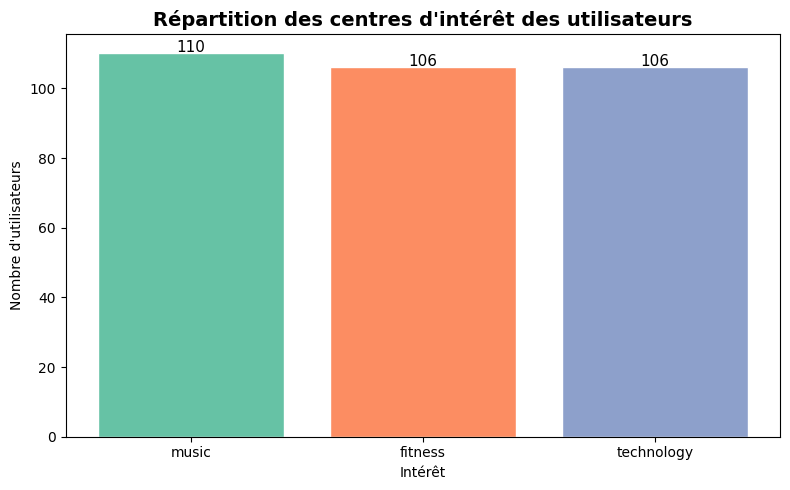

In [11]:
# Graphique 1 — Répartition des centres d'intérêt des utilisateurs
fig, ax = plt.subplots(figsize=(8, 5))
couleurs = sns.color_palette('Set2', len(freq_interets))
ax.bar(freq_interets.index, freq_interets.values, color=couleurs, edgecolor='white')
ax.set_title("Répartition des centres d'intérêt des utilisateurs", fontsize=14, fontweight='bold')
ax.set_xlabel('Intérêt')
ax.set_ylabel("Nombre d'utilisateurs")
for i, v in enumerate(freq_interets.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

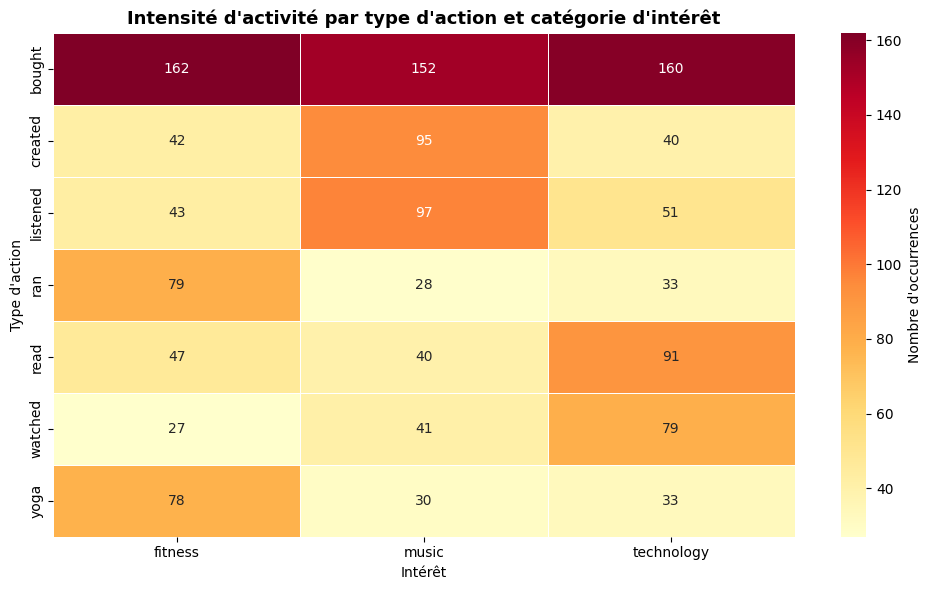

In [12]:
# Graphique 2 — Heatmap d'intensité d'activité par type d'action et intérêt
types_actions = ['watched', 'bought', 'read', 'listened', 'ran', 'yoga', 'created']

def detecter_type_action(action):
    for t in types_actions:
        if t in action:
            return t
    return 'other'

lignes = []
for _, row in df.iterrows():
    for interet in row['interests']:
        for action in row['activity_log']:
            lignes.append({'interet': interet, 'type_action': detecter_type_action(action)})

df_heatmap = pd.DataFrame(lignes)
matrice = df_heatmap.groupby(['type_action', 'interet']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrice, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': "Nombre d'occurrences"})
ax.set_title("Intensité d'activité par type d'action et catégorie d'intérêt", fontsize=13, fontweight='bold')
ax.set_xlabel('Intérêt')
ax.set_ylabel("Type d'action")
plt.tight_layout()
plt.show()

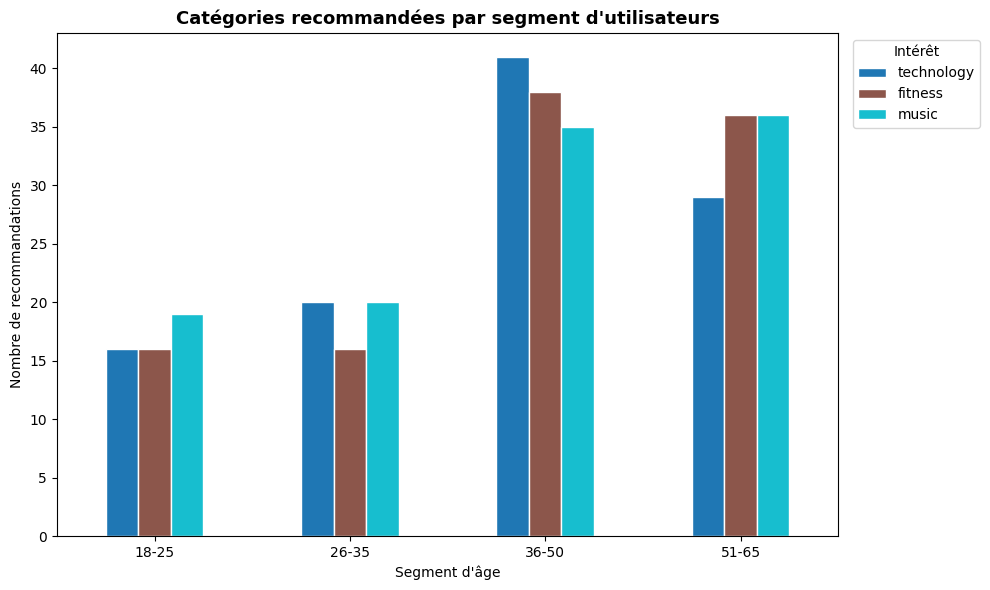

In [13]:
# Graphique 3 — Catégories recommandées par segment d'utilisateurs
df_seg = df.copy()
df_seg['segment'] = pd.cut(df_seg['age'], bins=[17, 25, 35, 50, 65],
                            labels=['18-25', '26-35', '36-50', '51-65'])

comptage = {seg: {i: 0 for i in INTERESTS} for seg in ['18-25', '26-35', '36-50', '51-65']}
for _, row in df_seg.iterrows():
    seg = str(row['segment'])
    if seg == 'nan':
        continue
    for interet in row['interests']:
        if interet in comptage[seg]:
            comptage[seg][interet] += 1

df_plot = pd.DataFrame(comptage).T
df_plot.index.name = "Segment d'âge"

fig, ax = plt.subplots(figsize=(10, 6))
df_plot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title("Catégories recommandées par segment d'utilisateurs", fontsize=13, fontweight='bold')
ax.set_xlabel("Segment d'âge")
ax.set_ylabel('Nombre de recommandations')
ax.legend(title='Intérêt', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Graphique 4 (Bonus) — Heatmap : Intensité d'activité par heure et catégorie

⚠️ df non trouvé. Régénération des données...
✓ 172 profils générés et nettoyés


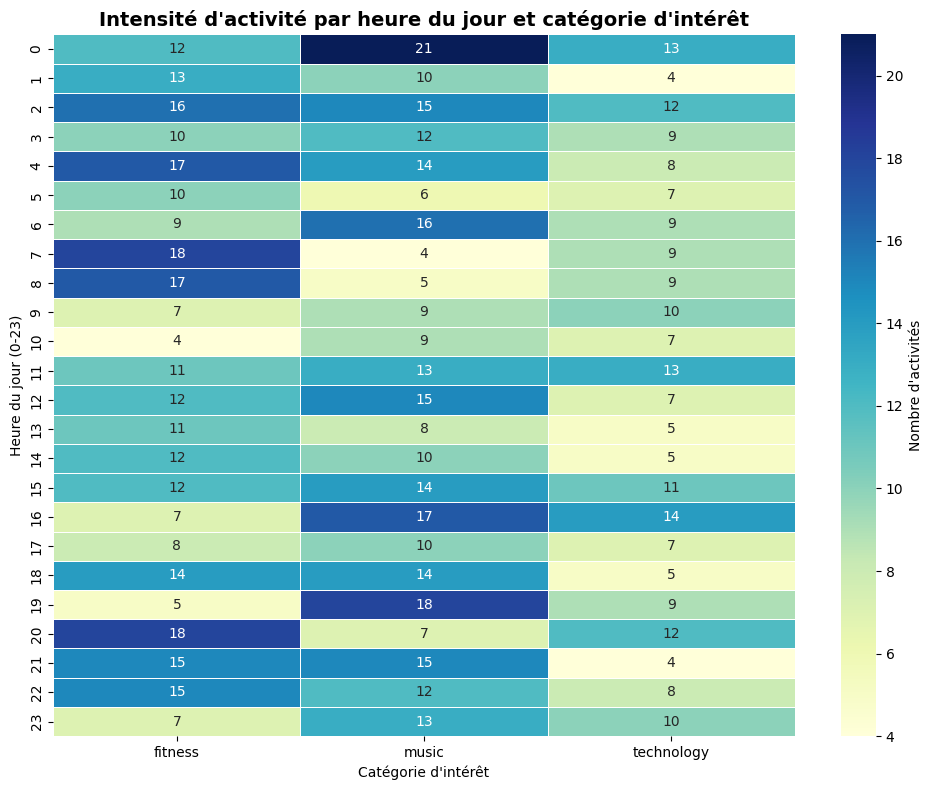


📊 STATISTIQUES D'ACTIVITÉ PAR HEURE
Heures de pointe : [0, 2, 4]
Heures creuses : [10, 5, 13]


In [ ]:

# Recréer df si nécessaire
try:
    df.shape
except NameError:
    print("⚠️ df non trouvé. Régénération des données...")
    
    fake = Faker('fr_FR')
   
    
    
    
    def generate_user(user_id):
        name = fake.name()
        age = np.random.randint(18, 66)
        num_interests = np.random.randint(1, 4)
        interests = list(np.random.choice(INTERESTS, size=num_interests, replace=False))
        num_activities = np.random.randint(3, 7)
        activity_log = []
        for _ in range(num_activities):
            chosen_interest = np.random.choice(interests)
            activity = np.random.choice(ACTIVITY_MAPPING[chosen_interest])
            activity_log.append(activity)
        return {"name": name, "age": age, "interests": interests, "activity_log": activity_log}
    
    def generate_users_dataset(n_users=100):
        users_list = [generate_user(i + 1) for i in range(n_users)]
        return pd.DataFrame(users_list)
    
    df_brut = generate_users_dataset(200)
    df_brut['age'] = df_brut['age'].astype(float)
    indices_age_manquant = np.random.choice(200, size=15, replace=False)
    indices_journal_manquant = np.random.choice(200, size=10, replace=False)
    indices_nom_doublon = np.random.choice(200, size=5, replace=False)
    
    for i in indices_age_manquant:
        df_brut.at[i, 'age'] = np.nan
    for i in indices_journal_manquant:
        df_brut.at[i, 'activity_log'] = None
    for i in indices_nom_doublon:
        df_brut.at[i, 'name'] = df_brut.at[0, 'name']
    
    df = df_brut.drop_duplicates(subset=['name']).dropna().reset_index(drop=True)
    print(f"✓ {len(df)} profils générés et nettoyés")


activity_records = []
for _, row in df.iterrows():
    for action in row['activity_log']:
        # Générer une heure aléatoire (0-23)
        heure = np.random.randint(0, 24)
        # Déterminer l'intérêt associé
        for interet in row['interests']:
            if interet in ACTIVITY_MAPPING and action in ACTIVITY_MAPPING[interet]:
                activity_records.append({'heure': heure, 'interet': interet, 'action': action})
                break
        else:
            # Si aucun intérêt détecté, assigner le premier intérêt
            activity_records.append({'heure': heure, 'interet': row['interests'][0], 'action': action})

df_activity = pd.DataFrame(activity_records)

# Créer la matrice heure × intérêt
matrice_heure = df_activity.groupby(['heure', 'interet']).size().unstack(fill_value=0)

# Graphique heatmap par heure et intérêt
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrice_heure, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'label': "Nombre d'activités"})
ax.set_title("Intensité d'activité par heure du jour et catégorie d'intérêt", fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie d\'intérêt')
ax.set_ylabel('Heure du jour (0-23)')
plt.tight_layout()
plt.show()

print("\n📊 STATISTIQUES D'ACTIVITÉ PAR HEURE")
print(f"Heures de pointe : {matrice_heure.sum(axis=1).nlargest(3).index.tolist()}")
print(f"Heures creuses : {matrice_heure.sum(axis=1).nsmallest(3).index.tolist()}")
